In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model19_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model19_0)
describe(model19_0)

MACs: 5.77 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model19_0.pt
Starting
Epoch 1/60: Train loss = 1.1566, Train accuracy = 0.5918, Test loss = 1.0556, Test accuracy = 0.6292
Epoch 2/60: Train loss = 0.9146, Train accuracy = 0.6802, Test loss = 0.9221, Test accuracy = 0.6820
Epoch 3/60: Train loss = 0.8132, Train accuracy = 0.7126, Test loss = 0.7770, Test accuracy = 0.7230
Epoch 4/60: Train loss = 0.7236, Train accuracy = 0.7484, Test loss = 0.7350, Test accuracy = 0.7482
Epoch 5/60: Train loss = 0.6959, Train accuracy = 0.7598, Test loss = 0.7034, Test accuracy = 0.7580
Epoch 6/60: Train loss = 0.6690, Train accuracy = 0.7690, Test loss = 0.6694, Test accuracy = 0.7746
Epoch 7/60: Train loss = 0.7112, Train accuracy = 0.7627, Test loss = 0.7671, Test accuracy = 0.7537
Epoch 8/60: Train loss = 0.6227, Train accuracy = 0.7798, Test loss = 0.6608, Test accuracy = 0.7740
Epoch 9/60: Train loss = 0.5775, Train accuracy = 0.7998, Test loss = 0.5993, Test accuracy = 0.7978
Epoch 10/60: Train loss = 0.544

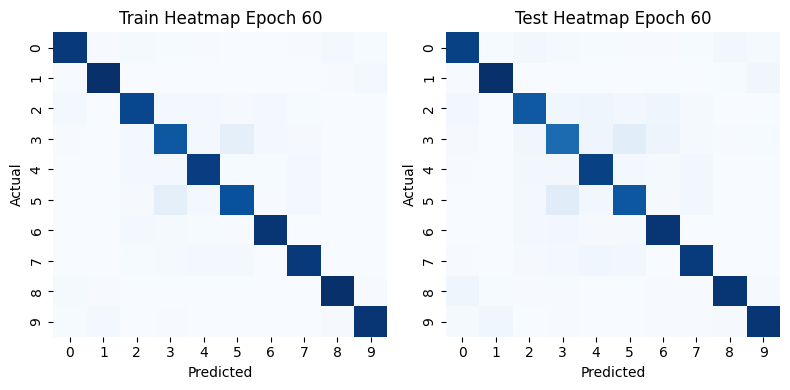

<Figure size 1200x600 with 0 Axes>

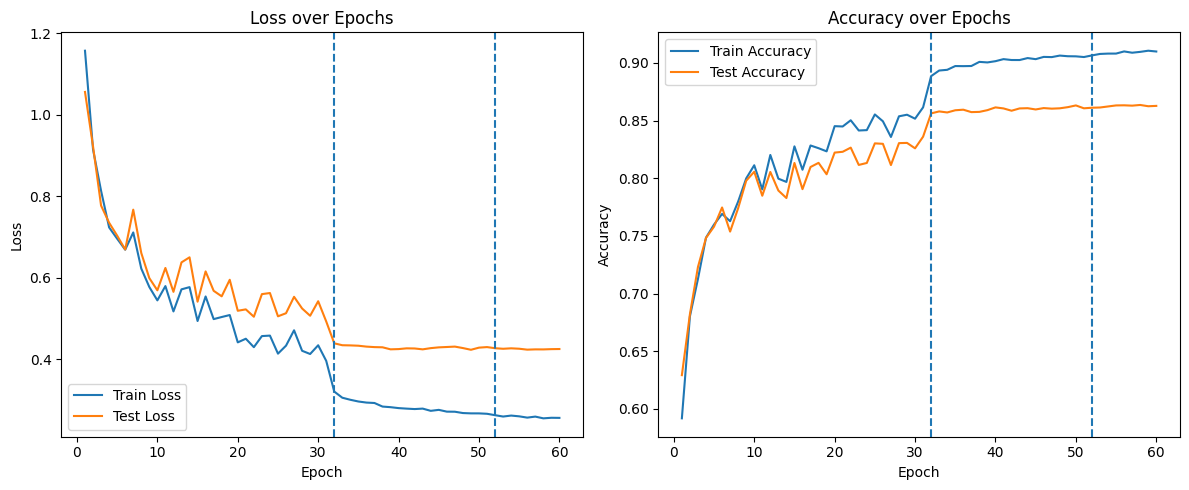

In [6]:
trainf32(model19_0,"model_weights/model19_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model19_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model19_1)
describe(model19_1)

MACs: 5.77 MMac, Params: 48.51 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model19_1.pt
Starting
Epoch 1/60: Train loss = 1.0859, Train accuracy = 0.6321, Test loss = 1.0333, Test accuracy = 0.6520
Epoch 2/60: Train loss = 0.8312, Train accuracy = 0.7125, Test loss = 0.8382, Test accuracy = 0.7142
Epoch 3/60: Train loss = 0.7653, Train accuracy = 0.7307, Test loss = 0.7718, Test accuracy = 0.7264
Epoch 4/60: Train loss = 0.6915, Train accuracy = 0.7581, Test loss = 0.7046, Test accuracy = 0.7535
Epoch 5/60: Train loss = 0.6994, Train accuracy = 0.7544, Test loss = 0.7286, Test accuracy = 0.7465


/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 6/60: Train loss = 0.6364, Train accuracy = 0.7812, Test loss = 0.6545, Test accuracy = 0.7734
Epoch 7/60: Train loss = 0.6290, Train accuracy = 0.7837, Test loss = 0.6537, Test accuracy = 0.7763
Epoch 8/60: Train loss = 0.5899, Train accuracy = 0.7960, Test loss = 0.6080, Test accuracy = 0.7896
Epoch 9/60: Train loss = 0.5384, Train accuracy = 0.8122, Test loss = 0.5870, Test accuracy = 0.7966
Epoch 10/60: Train loss = 0.5480, Train accuracy = 0.8091, Test loss = 0.5844, Test accuracy = 0.8008
Epoch 11/60: Train loss = 0.5049, Train accuracy = 0.8246, Test loss = 0.5404, Test accuracy = 0.8135
Epoch 12/60: Train loss = 0.4970, Train accuracy = 0.8251, Test loss = 0.5399, Test accuracy = 0.8139
Epoch 13/60: Train loss = 0.4914, Train accuracy = 0.8297, Test loss = 0.5386, Test accuracy = 0.8172
Epoch 14/60: Train loss = 0.4842, Train accuracy = 0.8334, Test loss = 0.5566, Test accuracy = 0.8149
Epoch 15/60: Train loss = 0.4962, Train accuracy = 0.8278, Test loss = 0.5817, Test ac

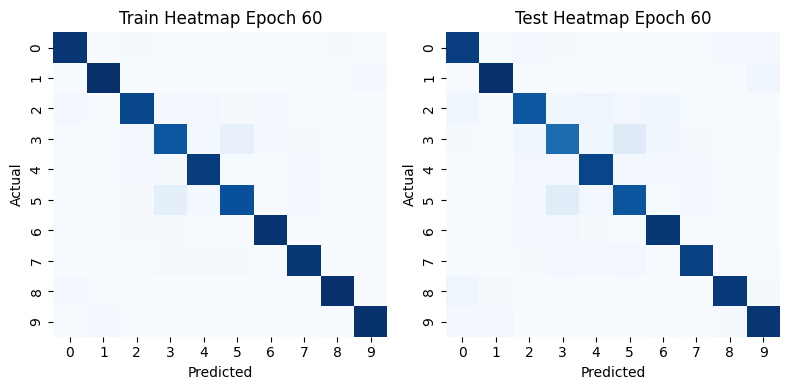

<Figure size 1200x600 with 0 Axes>

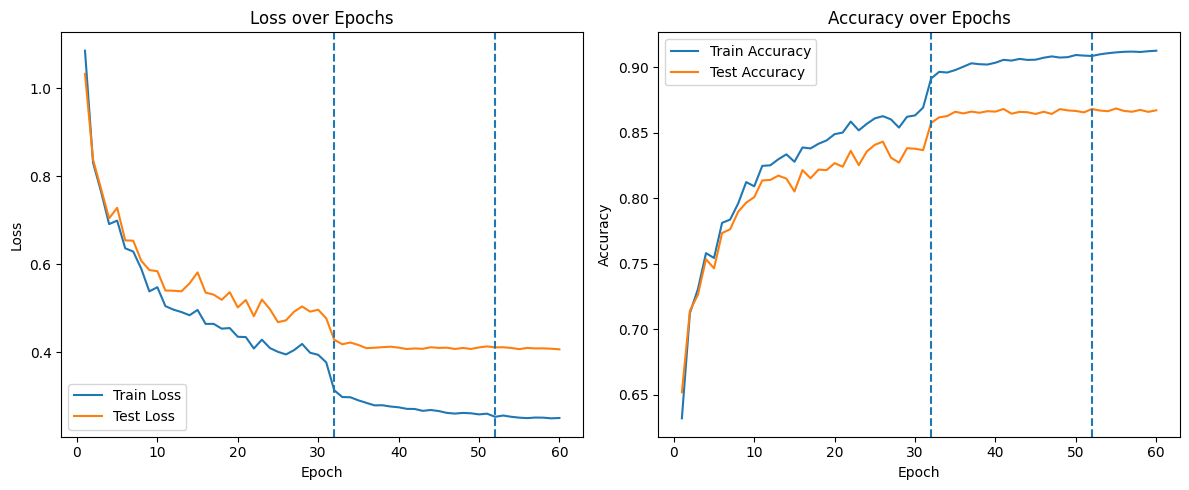

In [8]:
trainf32(model19_1,"model_weights/model19_1.pt",criterion,train_dataset,val_dataset, batch_size=64)